# Physio Regression and SCAN

In [1]:
# misc directory is at the same level as scan directory, 
# so we need to change the current working directory to the root directory
# ONLY RUN THIS CELL ONCE

import os
os.chdir(os.path.dirname(os.getcwd()))

In [2]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt

from scan.plots.snapshot import build_snapshot_plotter


261004-20:34:11,611 nipype.utils WARNING:
	 A newer version (1.11.0) of nipy/nipype is available. You are using 1.8.6


/Users/tbolt/Desktop/Research/SCAN/scan_physio/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Surface Plot

pixdim[1,2,3] should be non-zero; setting 0 dims to 1
pixdim[1,2,3] should be non-zero; setting 0 dims to 1
/var/folders/x9/qzst2v3x2ld1v31y4m1b7j0c0000gp/T/ipykernel_1888/1179806896.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


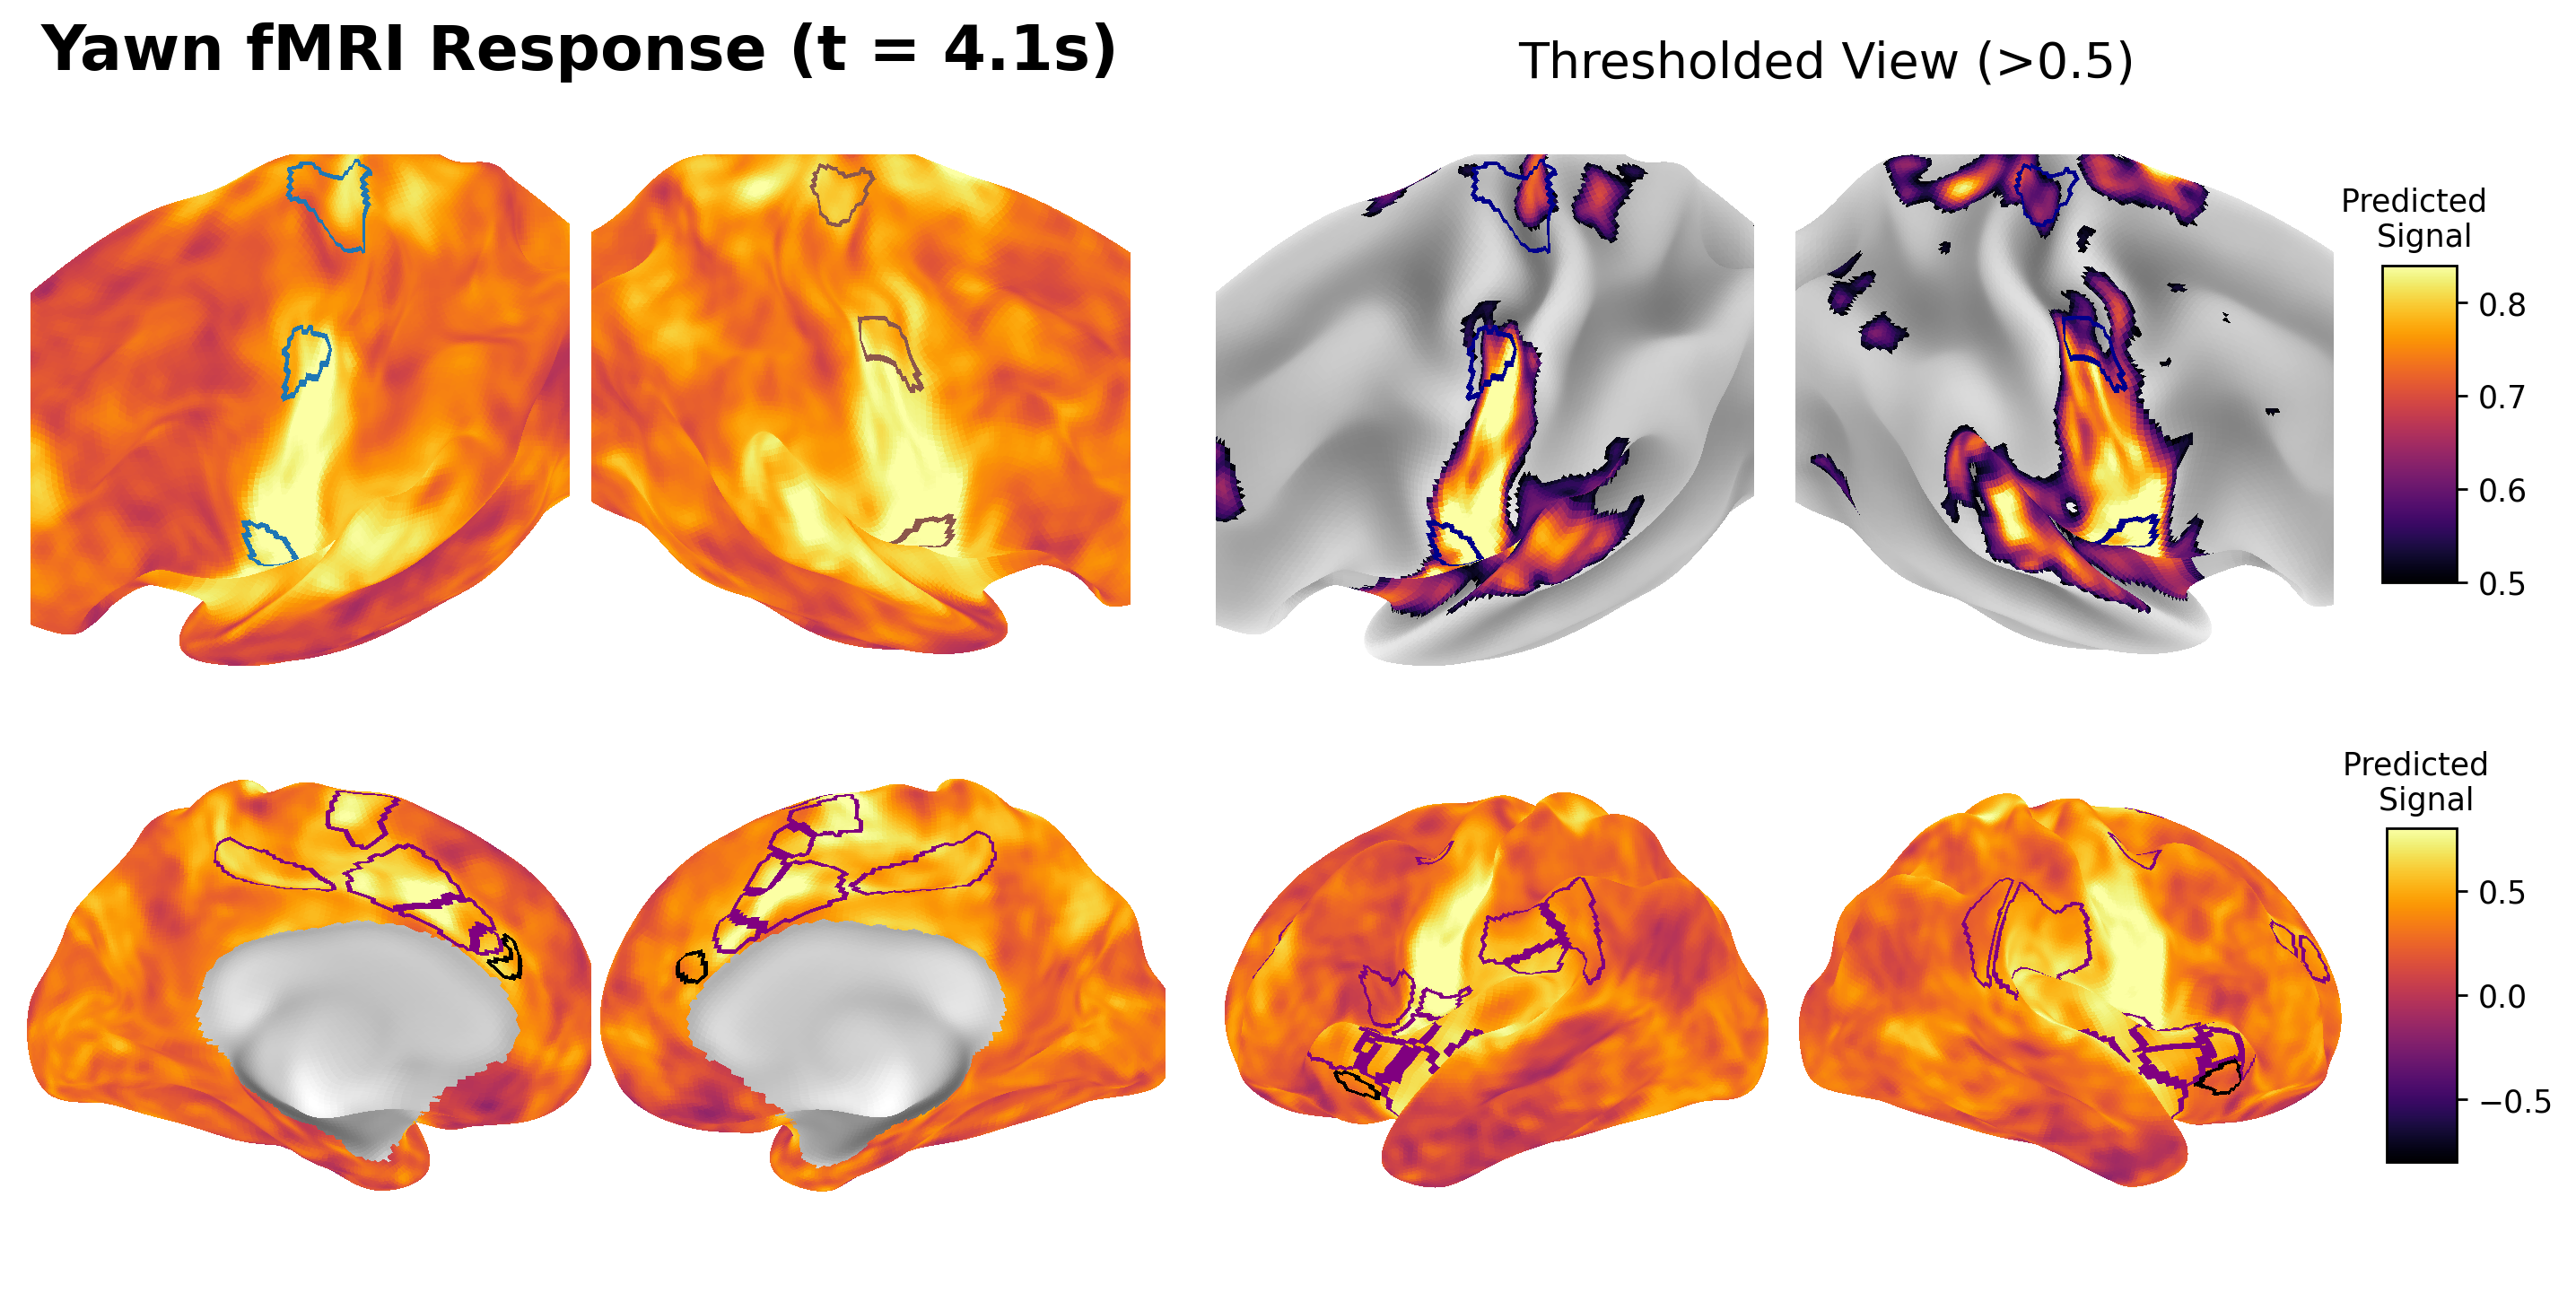

In [93]:
%matplotlib inline

# "yawn" or "sigh"
event = "yawn"
selected_index = 4

if event == "sigh":
    threshold = 0.2
    vmin = -0.4
    vmax = 0.4
elif event == "yawn":
    threshold = 0.5
    vmin = -0.8
    vmax = 0.8
else:
    raise ValueError(f"Unknown event type: {event}")

# get time units of the predicted fMRI response
glm_res = pickle.load(open(f"results/main/vanderbilt_glm_{event}.pkl", "rb"))
pred_times = glm_res['pred_lags']


# plot zoomed-in view of lateral motor cortex
plotter_all_scan = build_snapshot_plotter(
    input_left=Path(f"results/main/vanderbilt_glm_{event}_lh.func.gii"),
    input_right=Path(f"results/main/vanderbilt_glm_{event}_rh.func.gii"),
    roi_left=[Path("template/lh.SCAN_fsLR.label.gii")],
    roi_right=[Path("template/rh.SCAN_fsLR.label.gii")],
    index=selected_index,
    surf_views=("lateral",),
    colorbar=False,
    ncols=2,
    cmap="inferno",
    surf_zoom=2.2,
    # auto_percentiles=(1, 99.9),
    vmin=vmin,
    vmax=vmax,
    surf_elev_left=45,
    surf_azim_left=160,
    surf_elev_right=45,
    surf_azim_right=15,
    exclude_medial_wall=True
)

plotter_all_scan_threshold = build_snapshot_plotter(
    input_left=Path(f"results/main/vanderbilt_glm_{event}_lh.func.gii"),
    input_right=Path(f"results/main/vanderbilt_glm_{event}_rh.func.gii"),
    roi_left=[
        Path("template/lh.SCAN_fsLR.label.gii")
    ],
    roi_right=[
        Path("template/rh.SCAN_fsLR.label.gii")
    ],
    roi_left_color=["#00008B"],
    roi_right_color=['#00008B'],  
    index=selected_index,
    surf_views=("lateral",),
    colorbar=True,
    ncols=2,
    cmap="inferno",
    surf_zoom=2.2,
    auto_percentiles=(90, 99.9),
    vmin=threshold,
    threshold=threshold,
    surf_elev_left=45,
    surf_azim_left=160,
    surf_elev_right=45,
    surf_azim_right=15,
    exclude_medial_wall=True
)


plotter_all_lateral = build_snapshot_plotter(
    input_left=Path(f"results/main/vanderbilt_glm_{event}_lh.func.gii"),
    input_right=Path(f"results/main/vanderbilt_glm_{event}_rh.func.gii"),
    atlas='gordon',
    atlas_label_index=["CinguloOperc", "Salience"],
    index=selected_index,
    surf_views=("lateral",),
    # auto_percentiles=(1, 99.9),
    vmin=vmin,
    vmax=vmax,
    colorbar=False,
    ncols=2,
    cmap="inferno",
    surf_zoom=1.5,
    exclude_medial_wall=True
)

plotter_all_medial = build_snapshot_plotter(
    input_left=Path(f"results/main/vanderbilt_glm_{event}_lh.func.gii"),
    input_right=Path(f"results/main/vanderbilt_glm_{event}_rh.func.gii"),
    atlas='gordon',
    index=selected_index,
    surf_views=("medial",),
    colorbar=True,
    # auto_percentiles=(1, 99.9),
    vmin=vmin,
    vmax=vmax,
    atlas_label_index=["CinguloOperc", "Salience"],
    ncols=2,
    cmap="inferno",
    surf_zoom=1.55,
    exclude_medial_wall=True
)


# initialize figure grid
fig = plt.figure(figsize=(14, 7), dpi=250)
gs = fig.add_gridspec(2, 2, width_ratios= [0.5, 0.5], wspace=0.05, hspace=0)

brain_scan = gs[0,:].subgridspec(2, 2, width_ratios=[0.47, 0.53], height_ratios=[0.02, 0.98], wspace=0.05)
brain_scan_unthresholded = brain_scan[1, 0].subgridspec(1, 2, width_ratios=[0.5, 0.5], wspace=0.01)
brain_scan_thresholded_cbar = brain_scan[1, 1].subgridspec(1, 2, width_ratios=[0.94, 0.06], wspace=0.05)
brain_scan_thresholded = brain_scan_thresholded_cbar[0, 0].subgridspec(1, 2, width_ratios=[0.5, 0.5], wspace=0.01)
brain_cortex = gs[1,:].subgridspec(1, 3, width_ratios=[0.49, 0.49, 0.03], wspace=0.05)
brain_cortex_medial = brain_cortex[0, 0].subgridspec(1, 2, width_ratios=[1, 1], wspace=0.01)
brain_cortex_lateral = brain_cortex[0, 1].subgridspec(1, 2, width_ratios=[1, 1], wspace=0.01)
brain_cbar = brain_cortex[0, 2].subgridspec(3, 1, height_ratios=[0.15, 0.5, 0.15])
brain_cbar_threshold = brain_scan_thresholded_cbar[0, 1].subgridspec(3, 1, height_ratios=[0.2, 0.8, 0.2])


ax0 = fig.add_subplot(brain_scan_unthresholded[0, 0], projection="3d")
ax1 = fig.add_subplot(brain_scan_unthresholded[0, 1], projection="3d")
ax2 = fig.add_subplot(brain_scan_thresholded[0, 0], projection="3d")
ax3 = fig.add_subplot(brain_scan_thresholded[0, 1], projection="3d")
ax4 = fig.add_subplot(brain_cortex_medial[0, 0], projection="3d")
ax5 = fig.add_subplot(brain_cortex_medial[0, 1], projection="3d")
ax6 = fig.add_subplot(brain_cortex_lateral[0, 0], projection="3d")
ax7 = fig.add_subplot(brain_cortex_lateral[0, 1], projection="3d")
ax_cb = fig.add_subplot(brain_cbar[1,0])
ax_cb_threshold = fig.add_subplot(brain_cbar_threshold[1,0])

plotter_all_scan.render_into_axes(axes=[ax0, ax1])
plotter_all_scan_threshold.render_into_axes(axes=[ax2, ax3], colorbar_axis=ax_cb_threshold)
plotter_all_medial.render_into_axes(axes=[ax4, ax5])
plotter_all_lateral.render_into_axes(axes=[ax6, ax7], colorbar_axis=ax_cb)

ax_unthresholded_title = fig.add_subplot(brain_scan[0, 0])
ax_unthresholded_title.set_title(
    f"{event.capitalize()} fMRI Response (t = {round(pred_times[selected_index],1)}s)", 
    loc='center', fontsize=20, fontweight="bold"
)
ax_unthresholded_title.set_axis_off()


ax_thresholded_title = fig.add_subplot(brain_scan[0, 1])
ax_thresholded_title.set_title(f"Thresholded View (>{threshold})", loc='center', fontsize=16, pad=-0.1)
ax_thresholded_title.set_axis_off()


ax_cb.set_title("Predicted \n Signal", fontsize=10)
ax_cb_threshold.set_title("Predicted \n Signal", fontsize=10)



fig.tight_layout() 
# plt.show()

## Lateral Surface Plot with Threshold

Text(0.5, 0.98, 'Thresholded View (>0.4)')

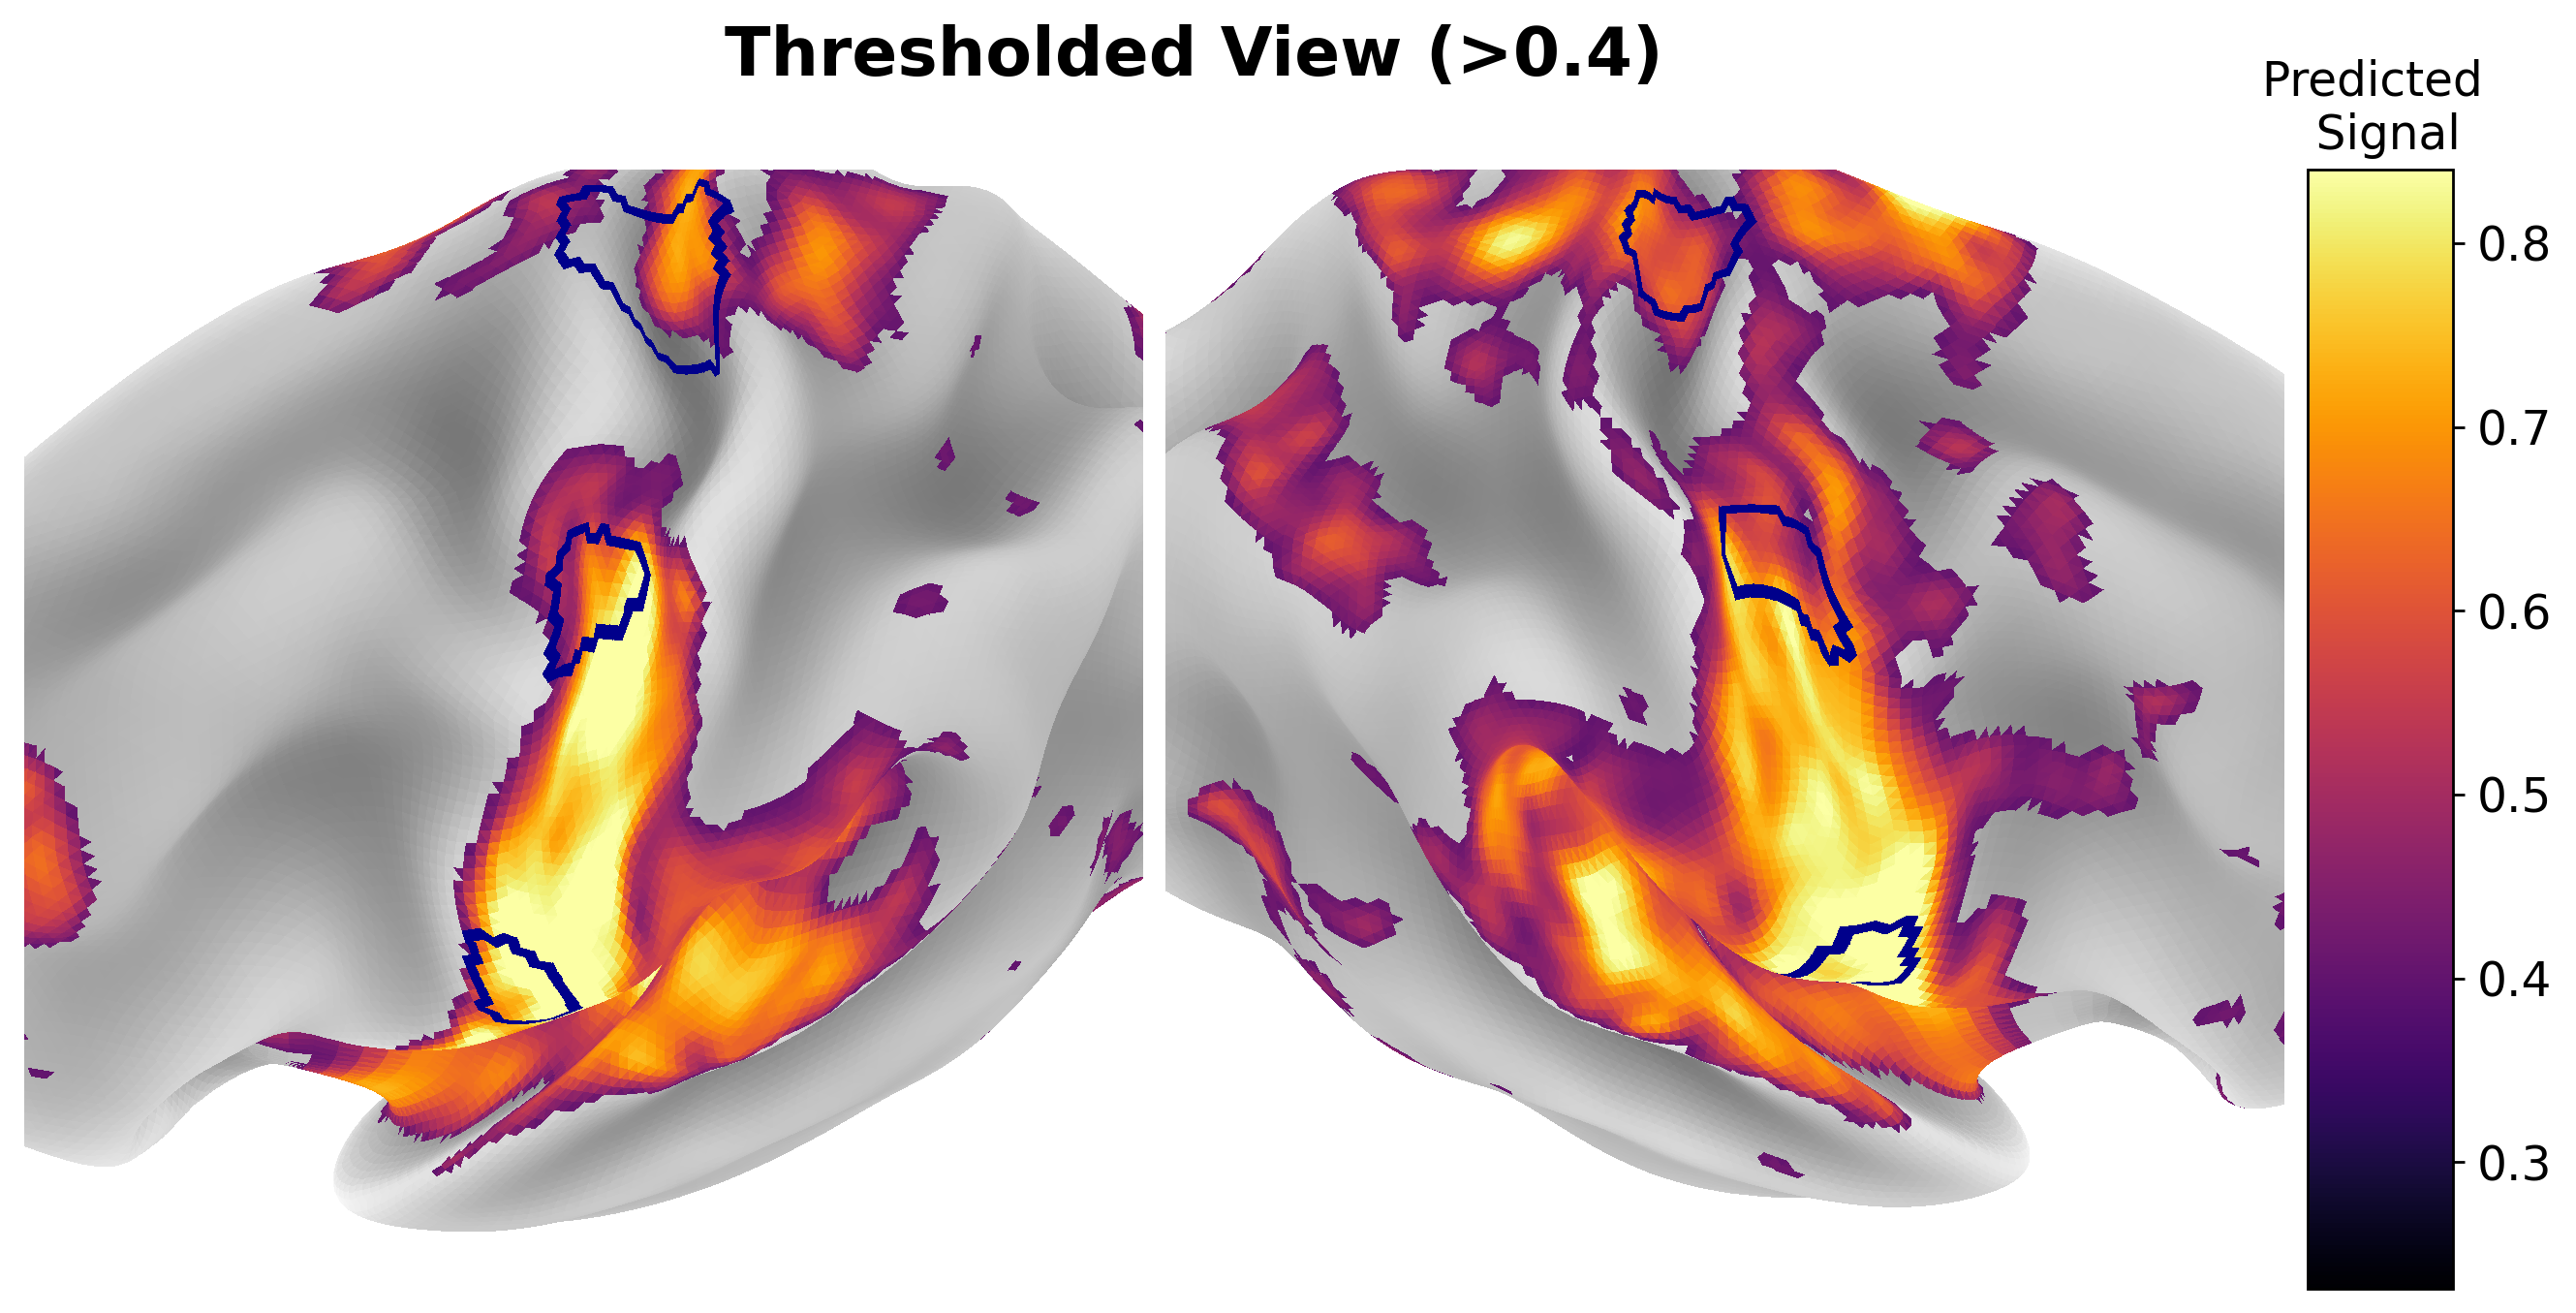

In [52]:
%matplotlib inline
# plot zoomed-in view of lateral motor cortex for simultaneous increase of respiratory, EOG and EMG
roi_scan = build_snapshot_plotter(
    input_left=Path("results/main/vanderbilt_glm_yawn_lh.func.gii"),
    input_right=Path("results/main/vanderbilt_glm_yawn_rh.func.gii"),
    roi_left=[
        Path("template/lh.SCAN_fsLR.label.gii")
    ],
    roi_right=[
        Path("template/rh.SCAN_fsLR.label.gii")
    ],
    roi_left_color=["#00008B"],
    roi_right_color=['#00008B'],  
    index=4,
    surf_views=("lateral",),
    colorbar=True,
    ncols=2,
    cmap="inferno",
    surf_zoom=2.2,
    auto_percentiles=(85, 99.9),
    threshold=0.4,
    surf_elev_left=45,
    surf_azim_left=160,
    surf_elev_right=45,
    surf_azim_right=15,
    exclude_medial_wall=True
)

# initialize figure grid
fig = plt.figure(figsize=(13, 6), dpi=250)
gs = fig.add_gridspec(1, 2, width_ratios= [0.94, 0.06], wspace=0.01, hspace=0)

brain_scan = gs[0,0].subgridspec(1, 2, width_ratios=[1, 1], wspace=0)
ax_cb = fig.add_subplot(gs[0, 1])
ax1 = fig.add_subplot(brain_scan[0, 0], projection="3d")
ax2 = fig.add_subplot(brain_scan[0, 1], projection="3d")
roi_scan.render_into_axes(axes=[ax1, ax2], colorbar_axis=ax_cb)
ax_cb.tick_params(labelsize=14) 
ax_cb.set_title("Predicted \n Signal", fontsize=14)
fig.suptitle("Thresholded View (>0.4)", fontweight="bold", fontsize=20)
